# Import Libraries

In [42]:
import pandas as pd   ## pandas is used for working with tables and datasets.
import numpy as np   ## numpy is used for numerical calculations.
import matplotlib.pyplot as plt  ## Matplotlib is used to create graphs and charts.
import seaborn as sns  ## Seaborn is used to create statistical graphs.

from sklearn.model_selection import train_test_split   ## Used to divide our data into training and testing data.
from sklearn.linear_model import LinearRegression   ## Imports the Linear Regression algorithm.
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## These metrics tell us how well our model is performing.

# Load Dataset

In [43]:
df=pd.read_csv(r'C:\Users\Dell\Downloads\house_data.csv')

# View the Dataset

In [44]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Price
0,850,1,1,20,1800000
1,900,2,1,18,2100000
2,950,2,1,15,2300000
3,1000,2,1,12,2500000
4,1050,2,2,10,2700000


# Check rows and columns

In [45]:
df.shape

(50, 5)

# Check columns names

In [46]:
df.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_House', 'Price'], dtype='str')

# Understand data types

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Area_sqft     50 non-null     int64
 1   Bedrooms      50 non-null     int64
 2   Bathrooms     50 non-null     int64
 3   Age_of_House  50 non-null     int64
 4   Price         50 non-null     int64
dtypes: int64(5)
memory usage: 2.1 KB


# Statistical Summary

In [48]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Price
count,50.000000,50.000000,50.000000,50.000000,5.000000e+01
mean,2075.000000,4.000000,3.560000,4.840000,6.710000e+06
std,728.868987,1.442786,1.500476,4.330056,2.900545e+06
min,850.000000,1.000000,1.000000,1.000000,1.800000e+06
25%,1462.500000,3.000000,2.000000,2.000000,4.250000e+06
50%,2075.000000,4.000000,3.500000,3.500000,6.700000e+06
75%,2687.500000,5.000000,5.000000,6.000000,9.150000e+06
max,3300.000000,6.000000,6.000000,20.000000,1.160000e+07


# Check missing values

In [49]:
df.isnull().sum()

Area_sqft       0
Bedrooms        0
Bathrooms       0
Age_of_House    0
Price           0
dtype: int64

# Check duplicate rows

In [50]:
df.duplicated().sum()

np.int64(0)

- If duplicates exist:

In [51]:
df=df.drop_duplicates()  

# Price distribution

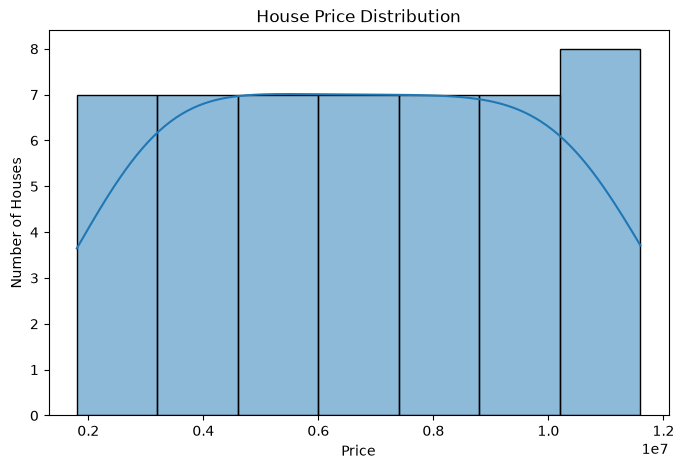

In [52]:
plt.figure(figsize=(8,5))   ## sets the graph size.

sns.histplot(df['Price'],kde=True)  ## Creates a histogram for the price column.

plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.show()  ## Display the graph

# Area vs Price

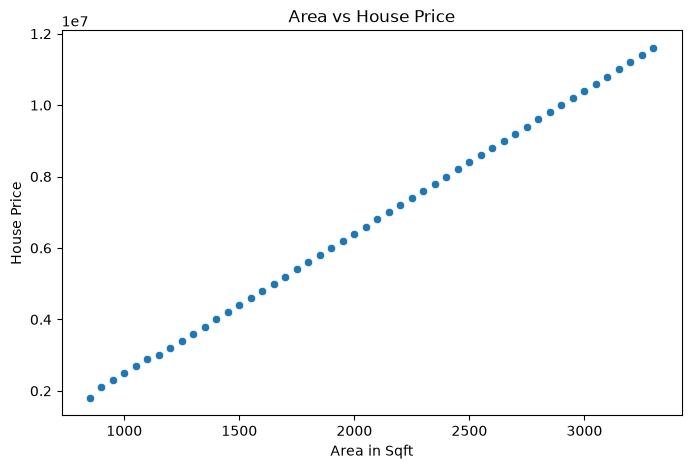

In [53]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Area_sqft',y='Price',data=df)

plt.title('Area vs House Price')
plt.xlabel('Area in Sqft')
plt.ylabel('House Price')

plt.show()

- This helps us understand:
Does house price increase when area increases?

# Separate input and target

- X=input features

In [54]:
x=df[['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_House']]

- y=target

In [55]:
y=df['Price']

# Train-test split

In [56]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

- Why split?

The model learns from training data.

Then we test it on data that it did not use during training.

# Create the model

# Model 1 - Linear Regression

In [57]:
lr_model=LinearRegression()  #3 This creates our LR model.

# Train the model

In [58]:
lr_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 3942.02,13465.3 ,17323.35, 4901.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Area_sqft','Bedrooms','Bathrooms','Age_of_House']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.609e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


- This is where the model learns the relationship between house features and price.

# Make predictions

In [59]:
y_pred1=lr_model.predict(x_test)

- The model takes the test houses and predicts their prices.

# Actual vs Predicted

- You can see actual vs predicted prices:

In [60]:
print('Actual',y_test.values)
print('Predicted',y_pred1)

Actual [ 4400000  9600000  7800000 10800000  5200000 11400000  7000000  6800000
  8200000  5600000]
Predicted [ 4408793.36312644  9587805.52237292  7811280.67226437 10801199.08549562
  5204716.07381189 11392501.54306783  7004510.13797622  6807409.31878548
  8200580.35411527  5594015.75566278]


In [61]:
result=pd.DataFrame({'Actual Price':y_test.values,
                     'Predicted Price':y_pred1})
result


,Actual Price,Predicted Price
0,4400000,4.408793e+06
1,9600000,9.587806e+06
2,7800000,7.811281e+06
3,10800000,1.080120e+07
4,5200000,5.204716e+06
5,11400000,1.139250e+07
6,7000000,7.004510e+06
7,6800000,6.807409e+06
8,8200000,8.200580e+06
9,5600000,5.594016e+06


# Evaluate the model

- Mean Absolute Error (MAE)

It tells us the average absolute difference between actual and predicted price.

In [62]:
lr_mae=mean_absolute_error(y_test,y_pred1)
print('MAE:',lr_mae)

MAE: 6416.618447176274


- Mean Squared Error (MSE)

MSE gives more penalty to larger errors.

In [63]:
lr_mse=mean_squared_error(y_test,y_pred1)
print('MSE:',lr_mse)

MSE: 54457544.161178015


- Root Mean Squared Error (RMSE)

RNSE is in the same unit as the target, so here it is in price units.

In [64]:
lr_rmse=np.sqrt(lr_mse)
print('RMSE:',lr_rmse)

RMSE: 7379.535497656882


- R2 Score

R2 tells us hou well the model explains variation in house prices.

In [65]:
lr_r2=r2_score(y_test,y_pred1)*100
print('R2 score:',lr_r2)

R2 score: 99.99891119753357


# Predict a new house price

- Create the input

In [66]:
new_house=pd.DataFrame({'Area_sqft': [1200],
                        'Bedrooms': [3],
                        'Bathrooms': [2],
                        'Age_of_House': [5]
                        })

- Now predict:

In [67]:
predicted_price=lr_model.predict(new_house)

print('Predicted House Price:',predicted_price[0])   ## The model will give the estimated price.

Predicted House Price: 3221286.4914514394


# Visualize Actual vs Predicted

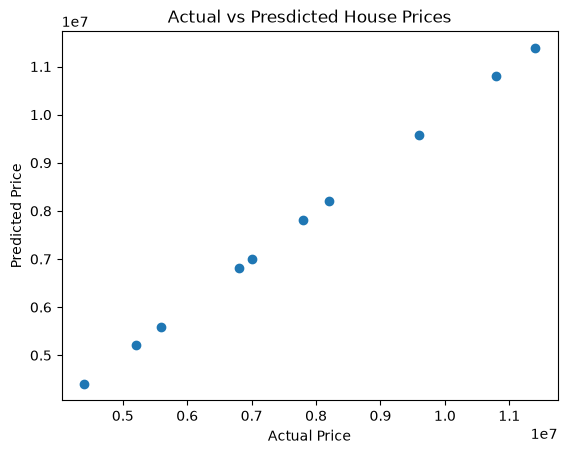

In [68]:
plt.scatter(y_test,y_pred1)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Presdicted House Prices')
plt.show()

# Model 2 - Decision Tree Regression

- A decision tree splits data according to different conditions to make predictions.

In [69]:
from sklearn.tree import DecisionTreeRegressor

In [70]:
dt_model=DecisionTreeRegressor(random_state=42,max_depth=5)

dt_model.fit(x_train,y_train)

y_pred2=dt_model.predict(x_test)
y_pred2

array([ 4100000.,  9300000.,  8000000., 10600000.,  5000000., 11200000.,
        7200000.,  6600000.,  7500000.,  5400000.])

# Evaluate

In [71]:
dt_mae=mean_absolute_error(y_test,y_pred2)
dt_rmse=np.sqrt(mean_squared_error(y_test,y_pred2))
dt_r2=r2_score(y_test,y_pred2)*100

print('Decision Tree')
print('MSE:',dt_mae)
print('RMSE:',dt_rmse)
print('R2 Score:',dt_r2)

Decision Tree
MSE: 270000.0
RMSE: 308220.7001484488
R2 Score: 98.10060780550224


# Model 3 - Random Forest Regression

-  In Random Forest, multiple decision trees combine to make a prediction.

In [72]:
from sklearn.ensemble import RandomForestRegressor

In [73]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)

rf_model.fit(x_train,y_train)

y_pred3=rf_model.predict(x_test)
y_pred3

array([ 4258000.,  9406000.,  7900000., 10754000.,  5088000., 11260000.,
        7146000.,  6962000.,  8124000.,  5408000.])

# Evaluate

In [74]:
rf_mae=mean_absolute_error(y_test,y_pred3)
rf_rmse=np.sqrt(mean_squared_error(y_test,y_pred3))
rf_r2=r2_score(y_test,y_pred3)*100

print('Random Forest')
print('MAE:',rf_mae)
print('RMSE:',rf_rmse)
print('R2 Score:',rf_r2)

Random Forest
MAE: 131000.0
RMSE: 138657.8522839583
R2 Score: 99.61560300703775


# Compare all models

In [75]:
comparison=pd.DataFrame({'Model':[
    'LinearRegression',
    'Decision Tree',
    'Random Forest'
],
'MAE':[lr_mae,
       dt_mae,
       rf_mae,],
       'RMSE':[
           lr_rmse,
           dt_rmse,
           rf_rmse
       ],
       'R2 Score':[
           lr_r2,
           dt_r2,
           rf_r2]})
print(comparison)

              Model            MAE           RMSE   R2 Score
0  LinearRegression    6416.618447    7379.535498  99.998911
1     Decision Tree  270000.000000  308220.700148  98.100608
2     Random Forest  131000.000000  138657.852284  99.615603


# New House Prediction

In [76]:
new_house=pd.DataFrame({'Area_sqft':[1200],
                        'Bedrooms':[3],
                        'Bathrooms':[2],
                        'Age_of_House':[5]})

- For example Linear Regression se:

In [77]:
new_prediction = lr_model.predict(new_house)
print('Predicted Price:',new_prediction[0])

Predicted Price: 3221286.4914514394


# Model Save

- Joblib --> It is library used to save and load ML model.

In [78]:
import joblib

In [79]:
joblib.dump(lr_model,'house_price_LR_model.pkl')

['house_price_LR_model.pkl']

# Load Model

In [81]:
model=joblib.load('house_price_LR_model.pkl')

# New House of Data

In [86]:
new_house1=pd.DataFrame({
    'Area_sqft':[1200],
    'Bedrooms':[3],
    'Bathrooms':[2],
    'Age_of_House':[5]
})

In [87]:
prediction=model.predict(new_house1)
print('Predicted House Price:',
      prediction[0])

Predicted House Price: 3221286.4914514394
